In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np

In [2]:
# Creating a sample dataset with missing values and categorical features
data = {'age': [25, 30, np.nan, 40, 45],
        'gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
        'city': ['New York', 'London', 'Paris', 'Tokyo', 'Sydney'],
        'income': [50000, 60000, 70000, np.nan, 90000]}

df = pd.DataFrame(data)

In [3]:
df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,London,60000.0
2,NaN,Male,Paris,70000.0
3,40.0,Female,Tokyo,NaN
4,45.0,Male,Sydney,90000.0


In [4]:
print(df.isnull().sum())

age       1
gender    0
city      0
income    1
dtype: int64


In [7]:
df.describe()

,age,income
count,4.000000,4.000000
mean,35.000000,67500.000000
std,9.128709,17078.251277
min,25.000000,50000.000000
25%,28.750000,57500.000000
50%,35.000000,65000.000000
75%,41.250000,75000.000000
max,45.000000,90000.000000


In [9]:
print("Missing values in the dataset:\n", df.isnull().sum())

Missing values in the dataset:
 age       1
gender    0
city      0
income    1
dtype: int64


In [10]:
df['age']

0    25.0
1    30.0
2     NaN
3    40.0
4    45.0
Name: age, dtype: float64

In [11]:
# 2. Replace missing values in 'age' column with the mean age.
df['age'].fillna(df['age'].mean(), inplace=True)

In [12]:
df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,London,60000.0
2,35.0,Male,Paris,70000.0
3,40.0,Female,Tokyo,NaN
4,45.0,Male,Sydney,90000.0


In [13]:
# 3. Replace missing values in 'income' column with the median income.
df['income'].fillna(df['income'].median(), inplace=True)
df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,London,60000.0
2,35.0,Male,Paris,70000.0
3,40.0,Female,Tokyo,65000.0
4,45.0,Male,Sydney,90000.0


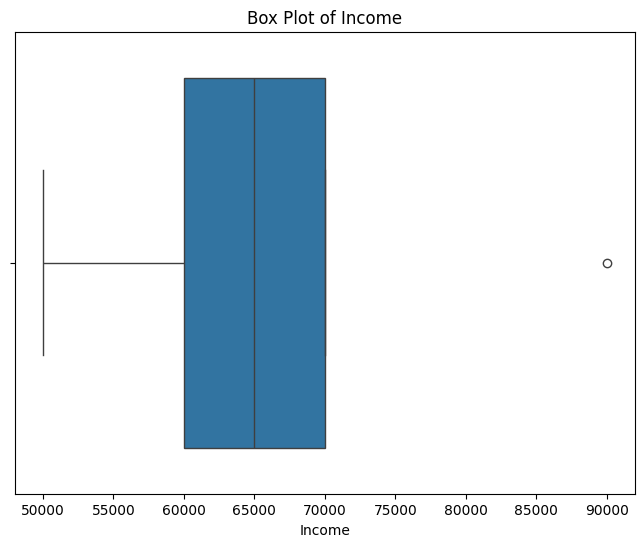

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot for the 'income' column
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['income'])
plt.title('Box Plot of Income')
plt.xlabel('Income')
plt.show()

In [63]:
# prompt: df['income'].fillna(df['income'].median(), inplace=True) - in this line median is used, when to use median and when to use mean for fillna()

import pandas as pd
import numpy as np

# ... (your existing code)

# Explanation of when to use mean vs. median for filling NaN values:

# Mean:
# - Use the mean when the data is normally distributed or approximately symmetric.
# - Sensitive to outliers. Extreme values can significantly skew the mean, leading to
#   imputed values that might not represent the typical value.

# Median:
# - Use the median when the data is skewed, contains outliers, or has a non-normal distribution.
# - Robust to outliers because it represents the middle value in the sorted dataset.
# - Less affected by extreme values, providing a more representative imputation for skewed data.


# Example illustrating the difference:

# Create a DataFrame with an outlier
data_with_outlier = {'income': [50000, 60000, 70000, 80000, 1000000]} # outlier: 1000000
df_outlier = pd.DataFrame(data_with_outlier)

# Calculate mean and median
mean_income = df_outlier['income'].mean()
median_income = df_outlier['income'].median()

print(f"Mean income with outlier: {mean_income}")
print(f"Median income with outlier: {median_income}")

# Impute using the mean and median for the example dataframe with outlier
df_outlier['income_mean'] = df_outlier['income'].fillna(df_outlier['income'].mean())
df_outlier['income_median'] = df_outlier['income'].fillna(df_outlier['income'].median())

df_outlier
# Observation: The mean is heavily influenced by the outlier (1,000,000). The median remains
# relatively stable.  In this case, the median would be a more appropriate choice for imputation
# as it provides a value closer to the central tendency of the data.


# In your original code:
# df['income'].fillna(df['income'].median(), inplace=True)

# It's likely that the income data might be skewed (some people earn significantly more
# than others), and using the median is a more robust approach in such cases.  If there is an
# overwhelming number of outliers in the income, the mean will be inflated. It may be best to visualize the data
# with a box plot to determine the best imputation strategy.


Mean income with outlier: 252000.0
Median income with outlier: 70000.0


,income,income_mean,income_median
0,50000,50000,50000
1,60000,60000,60000
2,70000,70000,70000
3,80000,80000,80000
4,1000000,1000000,1000000


# prompt: when to use mean and when to use median in my data pre-processing step

# When to use mean and median for imputation:

# Mean:
# - Use when the data is normally distributed or approximately normally distributed.
# - Sensitive to outliers, so if your data has extreme values, using the mean might skew the results.
# - Suitable for numerical features.

# Median:
# - Use when the data is skewed or has outliers.
# - Less sensitive to outliers compared to the mean, providing a more robust central tendency.
# - Suitable for numerical features.

# Example in the provided code:
# - The mean was used for the 'age' column. If 'age' is normally distributed or has few outliers, then the mean imputation is suitable. Otherwise median imputation is preferred.
# - The median was used for the 'income' column. This is a good choice if 'income' is skewed due to potential outliers (high earners).  The median would be a better representation of a typical income value.

In [13]:
df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,London,60000.0
2,35.0,Male,Paris,70000.0
3,40.0,Female,Tokyo,65000.0
4,45.0,Male,Sydney,90000.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     5 non-null      float64
 1   gender  5 non-null      object 
 2   city    5 non-null      object 
 3   income  5 non-null      float64
dtypes: float64(2), object(2)
memory usage: 292.0+ bytes


In [15]:
# prompt: explain to me step by step why i need to write these lines - from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()

# You would use LabelEncoder from sklearn.preprocessing if you wanted to convert
# categorical features (like 'city' in your example) into numerical labels.

# Here's a breakdown of why you might need it and how it works:

# 1. Many machine learning algorithms work best with numerical data:
#    Many algorithms cannot directly handle categorical data like strings
#    (e.g., 'New York', 'London').

# 2. LabelEncoder assigns a unique integer to each unique category:
#    It essentially maps each distinct value in a categorical column to a number.
#    For example, it might map 'New York' to 0, 'London' to 1, 'Paris' to 2, etc.

# Example using your data:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])

# Explanation of the code:
# - from sklearn.preprocessing import LabelEncoder: Imports the LabelEncoder class.
# - le = LabelEncoder(): Creates an instance of the LabelEncoder class.
# - df['city_encoded'] = le.fit_transform(df['city']):
#   - le.fit_transform() fits the encoder to your data and then transforms
#     the data (the 'city' column).
#   - The result is a new column, 'city_encoded', containing the numerical labels.

# Note: LabelEncoder is suitable when there's an inherent ordinal relationship
# between the categories (e.g., low, medium, high). If there's no such
# relationship, one-hot encoding might be more appropriate (as you've already
# done with 'gender').

In [16]:
df

,age,gender,city,income,city_encoded
0,25.0,Male,New York,50000.0,1
1,30.0,Female,London,60000.0,0
2,35.0,Male,Paris,70000.0,2
3,40.0,Female,Tokyo,65000.0,4
4,45.0,Male,Sydney,90000.0,3


In [17]:
# 2. Convert 'city' column to numerical using label encoding.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

In [18]:
df

,age,gender,city,income,city_encoded,gender_encoded
0,25.0,Male,New York,50000.0,1,1
1,30.0,Female,London,60000.0,0,0
2,35.0,Male,Paris,70000.0,2,1
3,40.0,Female,Tokyo,65000.0,4,0
4,45.0,Male,Sydney,90000.0,3,1


In [19]:
df[['age', 'income']]

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,35.0,70000.0
3,40.0,65000.0
4,45.0,90000.0


In [20]:
# Exercise 3: Feature scaling
# 1. Apply min-max scaling to 'age' and 'income' columns.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['age', 'income']] = scaler.fit_transform(df[['age', 'income']])

In [21]:
df

,age,gender,city,income,city_encoded,gender_encoded
0,0.00,Male,New York,0.000,1,1
1,0.25,Female,London,0.250,0,0
2,0.50,Male,Paris,0.500,2,1
3,0.75,Female,Tokyo,0.375,4,0
4,1.00,Male,Sydney,1.000,3,1


In [22]:
# Exercise 4: Data splitting
# 1. Split the dataset into training and testing sets (80% training, 20% testing).
from sklearn.model_selection import train_test_split
X = df.drop('income', axis=1)  # Features
y = df['income']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

In [23]:
print(X)

    age  gender      city  city_encoded  gender_encoded
0  0.00    Male  New York             1               1
1  0.25  Female    London             0               0
2  0.50    Male     Paris             2               1
3  0.75  Female     Tokyo             4               0
4  1.00    Male    Sydney             3               1


In [24]:
print(y)

0    0.000
1    0.250
2    0.500
3    0.375
4    1.000
Name: income, dtype: float64


In [25]:
print(y_train)

4    1.000
2    0.500
0    0.000
3    0.375
Name: income, dtype: float64


In [26]:
print(X_train)

    age  gender      city  city_encoded  gender_encoded
4  1.00    Male    Sydney             3               1
2  0.50    Male     Paris             2               1
0  0.00    Male  New York             1               1
3  0.75  Female     Tokyo             4               0


In [27]:
print(X_test)

    age  gender    city  city_encoded  gender_encoded
1  0.25  Female  London             0               0


In [28]:
print(y_test)

1    0.25
Name: income, dtype: float64


In [30]:
print("\nPreprocessed Data:\n", df)


Preprocessed Data:
     age  gender      city  income  city_encoded  gender_encoded
0  0.00    Male  New York   0.000             1               1
1  0.25  Female    London   0.250             0               0
2  0.50    Male     Paris   0.500             2               1
3  0.75  Female     Tokyo   0.375             4               0
4  1.00    Male    Sydney   1.000             3               1


In [66]:
# Install the Kaggle API client
%pip install kaggle


   ----------------------------------------  0/12 [webencodings]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ------ ---------------------------------  2/12 [urllib3]
   ---------- -----------------------------  3/12 [python-slugify]
   ---------- -----------------------------  3/12 [python-slugify]
   ---------- -----------------------------  3/12 [python-slugify]
   ------------- --------------------------  4/12 [protobuf]
   ------------- --------------------------  4/12 [protobuf]
   ------------- --------------------------  4/12 [protobuf]
   ------------- --------------------------  4/12 [protobuf]
   ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [71]:
# Make a directory for the Kaggle credentials
!mkdir ~/.kaggle
# Copy the uploaded kaggle.json file to the correct directory
!cp kaggle.json ~/.kaggle/
# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [82]:
import os

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
!copy kaggle.json %USERPROFILE%\.kaggle\

The system cannot find the file specified.


In [ ]:
import shutil
import os

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

try:
    shutil.copy("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
except FileNotFoundError:
    print("kaggle.json not found in the current directory. Please upload or place the kaggle.json file in the notebook's working directory.")

In [ ]:
# Install the Kaggle API client
%pip install kaggle
# Download the dataset
%kaggle datasets download -d zillow/zecon

o use the Kaggle API, you need to upload your kaggle.json file. You can get this file from your Kaggle account settings under the "API" section. Click on "Create New API Token" to download it.

Once you have the file, click the folder icon in the left sidebar, then click the "Upload to session storage" icon and select your kaggle.json file.

In [ ]:
# Make a directory for the Kaggle credentials
!mkdir ~/.kaggle
# Copy the uploaded kaggle.json file to the correct directory
!cp kaggle.json ~/.kaggle/
# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

Now we can download the Iris dataset using the Kaggle API command. The dataset is located at uciml/iris.